In [ ]:
import pandas
import matplotlib.pyplot as plt
import numpy as np


In [5]:
df = pandas.read_csv("agri_data.csv")
print(df.head())

                         State                  District      Crop     Year  \
0  Andaman and Nicobar Islands                  NICOBARS  Arecanut  2001-02   
1  Andaman and Nicobar Islands                  NICOBARS  Arecanut  2002-03   
2  Andaman and Nicobar Islands                  NICOBARS  Arecanut  2003-04   
3  Andaman and Nicobar Islands  NORTH AND MIDDLE ANDAMAN  Arecanut  2001-02   
4  Andaman and Nicobar Islands            SOUTH ANDAMANS  Arecanut  2002-03   

       Season    Area Area Units  Production Production Units     Yield  
0      Kharif  1254.0    Hectare      2061.0           Tonnes  1.643541  
1  Whole Year  1258.0    Hectare      2083.0           Tonnes  1.655803  
2  Whole Year  1261.0    Hectare      1525.0           Tonnes  1.209358  
3      Kharif  3100.0    Hectare      5239.0           Tonnes  1.690000  
4  Whole Year  3105.0    Hectare      5267.0           Tonnes  1.696296  


In [7]:
x = df.iloc[:, 0]
y = df.iloc[:, 1]

In [14]:
def generate_state_code(state):
    words = state.lower().split()

    if(len(words) == 1):
        return words[0][0].upper()
    else:
        return ''.join(word[0].upper() for word in words).upper()

df['State_Code'] = df['State'].apply(generate_state_code)
print(df.head())    
    

                         State                  District      Crop     Year  \
0  Andaman and Nicobar Islands                  NICOBARS  Arecanut  2001-02   
1  Andaman and Nicobar Islands                  NICOBARS  Arecanut  2002-03   
2  Andaman and Nicobar Islands                  NICOBARS  Arecanut  2003-04   
3  Andaman and Nicobar Islands  NORTH AND MIDDLE ANDAMAN  Arecanut  2001-02   
4  Andaman and Nicobar Islands            SOUTH ANDAMANS  Arecanut  2002-03   

       Season    Area Area Units  Production Production Units     Yield  \
0      Kharif  1254.0    Hectare      2061.0           Tonnes  1.643541   
1  Whole Year  1258.0    Hectare      2083.0           Tonnes  1.655803   
2  Whole Year  1261.0    Hectare      1525.0           Tonnes  1.209358   
3      Kharif  3100.0    Hectare      5239.0           Tonnes  1.690000   
4  Whole Year  3105.0    Hectare      5267.0           Tonnes  1.696296   

  State_Code  
0       AANI  
1       AANI  
2       AANI  
3       AANI  

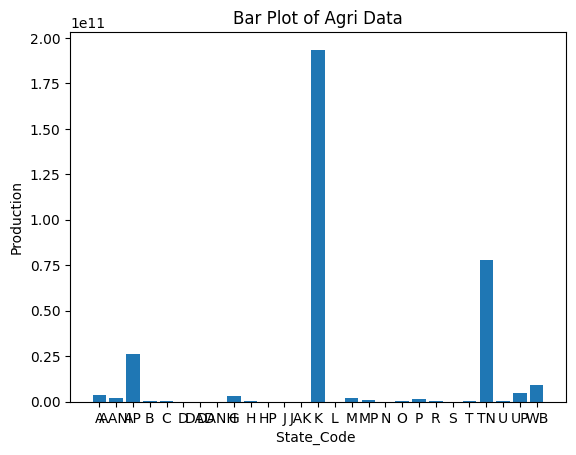

In [19]:
state_production = df.groupby('State_Code')['Production'].sum()

plt.bar(state_production.index, state_production.values)
plt.xlabel("State_Code ")
plt.ylabel("Production")
plt.title("Bar Plot of Agri Data")
plt.show(
)



In [27]:
print(df.shape)
print(df.columns)
print(df['Production Units'].unique())  
print(df['Crop'].unique())

(345407, 9)
Index(['State', 'District', 'Crop', 'Year', 'Season', 'Area', 'Production',
       'Production Units', 'Yield'],
      dtype='str')
<StringArray>
['Tonnes', 'Nuts', 'Bales']
Length: 3, dtype: str
<StringArray>
[             'Arecanut',                'Banana',          'Black pepper',
             'Cashewnut',               'Coconut',          'Dry chillies',
                'Ginger',   'Other Kharif pulses',        'other oilseeds',
                  'Rice',             'Sugarcane',          'Sweet potato',
             'Arhar/Tur',                 'Bajra',           'Castor seed',
             'Coriander',          'Cotton(lint)',                  'Gram',
             'Groundnut',            'Horse-gram',                 'Jowar',
               'Linseed',                 'Maize',                 'Mesta',
     'Moong(Green Gram)',            'Niger seed',                 'Onion',
     'Other Rabi pulses',                'Potato',                  'Ragi',
     'Rapeseed &Mu

11 features we Have Here , from which we have to eliminate state code and area unit as it consistent as hectare in all 

let's do one thing let's neutralize production units to one single tonnes from ['Tonnes', 'Nuts', 'Bales']
Length: 3, dtype: str by change that row production value too wrt to units

let's leave this it's complicated to convert that things 

In [30]:
df = df.drop(columns=[ 'District', 'Season'])
print(df.head())    

                         State      Crop     Year    Area  Production  \
0  Andaman and Nicobar Islands  Arecanut  2001-02  1254.0      2061.0   
1  Andaman and Nicobar Islands  Arecanut  2002-03  1258.0      2083.0   
2  Andaman and Nicobar Islands  Arecanut  2003-04  1261.0      1525.0   
3  Andaman and Nicobar Islands  Arecanut  2001-02  3100.0      5239.0   
4  Andaman and Nicobar Islands  Arecanut  2002-03  3105.0      5267.0   

  Production Units     Yield  
0           Tonnes  1.643541  
1           Tonnes  1.655803  
2           Tonnes  1.209358  
3           Tonnes  1.690000  
4           Tonnes  1.696296  


Drop rows where Yield is null or zero (bad records) or fix it .

In [33]:
df['Yield'] = pandas.to_numeric(df['Yield'], errors='coerce')
df['Production'] = pandas.to_numeric(df['Production'], errors='coerce') 
df['Area'] = pandas.to_numeric(df['Area'], errors='coerce')

bad_Yield = df['Yield'].isna() | df['Yield'] == 0
print(df[bad_Yield])
can_compute = df['Production'].notna() & df['Area'].notna() &(df['Area']!= 0)
df.loc[bad_Yield & can_compute, 'Yield'] = df['Production']/ df['Area']

df = df.dropna(subset=['Yield'])
df = df[df['Yield']!=0]

Empty DataFrame
Columns: [State, Crop, Year, Area, Production, Production Units, Yield]
Index: []


Parse Year into a usable integer , # Taking first year as base year for consistency

In [35]:
df['Year'] = df['Year'].str[:4].astype(int)
print(df.head())


                         State      Crop  Year    Area  Production  \
0  Andaman and Nicobar Islands  Arecanut  2001  1254.0      2061.0   
1  Andaman and Nicobar Islands  Arecanut  2002  1258.0      2083.0   
2  Andaman and Nicobar Islands  Arecanut  2003  1261.0      1525.0   
3  Andaman and Nicobar Islands  Arecanut  2001  3100.0      5239.0   
4  Andaman and Nicobar Islands  Arecanut  2002  3105.0      5267.0   

  Production Units     Yield  
0           Tonnes  1.643541  
1           Tonnes  1.655803  
2           Tonnes  1.209358  
3           Tonnes  1.690000  
4           Tonnes  1.696296  
